# **APRENDIZAJE AUTOMÁTICO I**

### ***TRABAJO PRÁCTICO II: CLASIFICACIÓN***


---


**Integrantes:**


*   Gómez Betsabé

*   Gómez Micaela





In [118]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, roc_auc_score)
from sklearn.dummy import DummyClassifier
from sklearn.impute import KNNImputer
from sklearn.metrics import matthews_corrcoef
from sklearn.model_selection import cross_val_score
import numpy as np
import warnings


In [119]:
#Lee el dataset
clima = pd.read_csv('/content/weatherAUS_2026C1.csv')

# **Datos**

El conjunto de datos tiene información climática de Australia de los últimos diez años. A continuación se detalla una breve descripción de sus columnas:

**Unnamed: 0**: Es un índice de fila (un número de identificación secuencial).

**Date:** La fecha exacta en la que se realizó la observación.

**Location:** El nombre de la ubicación o ciudad donde se encuentra la estación meteorológica.

**MinTemp:** La temperatura mínima registrada durante ese día (en grados Celsius).

**MaxTemp:** La temperatura máxima registrada durante ese día (en grados Celsius).

**Rainfall:** La cantidad total de lluvia caída durante el día (medida en milímetros).

**Evaporation:** La cantidad de agua evaporada en las últimas 24 horas hasta las 9:00 a.m. (en milímetros).

**Sunshine:** La cantidad total de horas de luz solar brillante registradas en el día.

**WindGustDir:** La dirección de la ráfaga de viento más fuerte registrada en el día (por ejemplo, N, S, SW, etc.).

**WindGustSpeed:** La velocidad máxima de esa ráfaga de viento más fuerte (en kilómetros por hora).

**WindDir9am:** La dirección del viento registrada a las 9:00 a.m.

**WindDir3pm:** La dirección del viento registrada a las 3:00 p.m.

**WindSpeed9am:** La velocidad promedio del viento registrada en los 10 minutos previos a las 9:00 a.m. (en km/h).

**WindSpeed3pm:** La velocidad promedio del viento registrada en los 10 minutos previos a las 3:00 p.m. (en km/h).

**Humidity9am:** El porcentaje de humedad relativa en el aire medido a las 9:00 a.m.

**Humidity3pm:** El porcentaje de humedad relativa en el aire medido a las 3:00 p.m.

**Pressure9am:** La presión atmosférica reducida al nivel del mar, medida a las 9:00 a.m. (en hectopascales, hPa).

**Pressure3pm:** La presión atmosférica reducida al nivel del mar, medida a las 3:00 p.m. (en hectopascales, hPa).

**Cloud9am:** La fracción del cielo cubierta por nubes a las 9:00 a.m. Se mide en "oktas" (octavos), siendo 0 un cielo completamente despejado y 8 un cielo totalmente nublado.

**Cloud3pm:** La fracción del cielo cubierta por nubes a las 3:00 p.m. (también en oktas).

**Temp9am:** La temperatura ambiente medida a las 9:00 a.m. (en grados Celsius).

**Temp3pm:** La temperatura ambiente medida a las 3:00 p.m. (en grados Celsius).

**RainToday:** Una variable categórica (Sí/No o True/False) que indica si la precipitación (Rainfall) en esas 24 horas superó 1 mm (es decir, si llovió ese día).

**RainTomorrow:** Una variable categórica (Sí/No) que indica si llovió al día siguiente. En modelos predictivos, esta suele ser la variable principal que se intenta predecir (la variable objetivo o target).

**RainfallTomorrow:** La cantidad exacta de lluvia (en milímetros) que se registrará al día siguiente.

In [120]:
clima.head(5)

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


Se observa que la columna Unnamed: 0 es un identificador por lo que no aporta información relevante para el modelo, además la columna "Rainfalltomorrow" hace referencia a la cantidad de milimetros y esta información no la tendriamos ya que tenemos que predecir si llueve o no al dia siguiente, por lo tanto se procede a su eliminación.

In [121]:
#Borra la columna Unnamed: 0
clima = clima.drop(columns=['Unnamed: 0','RainfallTomorrow'])

In [122]:
clima.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45304 entries, 0 to 45303
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           45304 non-null  object 
 1   Location       45304 non-null  object 
 2   MinTemp        44787 non-null  float64
 3   MaxTemp        44922 non-null  float64
 4   Rainfall       44077 non-null  float64
 5   Evaporation    22213 non-null  float64
 6   Sunshine       16918 non-null  float64
 7   WindGustDir    40158 non-null  object 
 8   WindGustSpeed  40163 non-null  float64
 9   WindDir9am     40510 non-null  object 
 10  WindDir3pm     43129 non-null  object 
 11  WindSpeed9am   44424 non-null  float64
 12  WindSpeed3pm   43791 non-null  float64
 13  Humidity9am    44597 non-null  float64
 14  Humidity3pm    43934 non-null  float64
 15  Pressure9am    38551 non-null  float64
 16  Pressure3pm    38592 non-null  float64
 17  Cloud9am       27086 non-null  float64
 18  Cloud3

Se decide convertir la columna "Date" a tipo de datos "datatime", además se crea una columna con cada número de dia/mes/año y se elimina la columna Date original porque no puede utilizarse directamente en regresión logística debido a que el modelo no interpreta fechas cronológicamente. Por este motivo se extrajeron variables derivadas como mes, día y año.

In [123]:
clima['Date'] = pd.to_datetime(clima['Date'])

clima['Year'] = clima['Date'].dt.year
clima['Month'] = clima['Date'].dt.month
clima['Day'] = clima['Date'].dt.day

clima = clima.drop('Date', axis=1)

Se observan valores nulos en la target "RainTomorrow", se calcula el porcentaje de los mismos.

In [124]:
#Porcentaje de los datos NaN en la variable target
print(f"{round((clima['RainTomorrow'].isnull().sum()/len(clima))*100,2)} %")

2.71 %


Como representa el 2.24% se procede a eliminar estos registros.

In [125]:
#Se eliminan las filas en la que la target es NaN
clima_limpio = clima.dropna(subset=['RainTomorrow'])

# **Modelo**

Se realiza primero la división de los conjuntos para evitar fuga de datos
Se divide en:
- Entrenamiento (Train) que representa el 64% del dataset original
- Validación 16%
- Test 20%

In [126]:
X = clima_limpio.drop('RainTomorrow', axis=1)
y = clima_limpio['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train)

Se utilizó stratify=y para conservar la proporción de clases en ambos conjuntos, ya que el dataset presenta desbalance entre días con lluvia y sin lluvia.

In [127]:
#Reseteo de indices
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

X_val = X_val.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)

X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# **Visualización y limpieza de los datos**

A continuación se realiza un análisis exploratorio de los datos de entrenamiento para comprender la distribución de las variables, detectar valores atípicos y extraer conclusiones que guíen las decisiones de preprocesamiento.

In [128]:
#Se observa las primeras 5 filas
X_train.head(5)

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,Year,Month,Day
0,Richmond,16.5,24.4,0.0,NaN,NaN,SE,38.0,S,SE,...,1015.4,1016.4,8.0,8.0,22.2,20.3,No,2015,11,21
1,Sydney,16.5,27.3,0.0,5.4,10.6,W,23.0,W,ENE,...,1013.7,1011.0,2.0,2.0,19.6,25.0,No,2013,4,14
2,BadgerysCreek,17.1,27.7,0.0,NaN,NaN,SSE,31.0,SSE,SE,...,1002.4,1002.6,NaN,NaN,23.0,23.8,No,2012,2,6
3,Williamtown,3.8,17.9,0.0,NaN,NaN,WNW,46.0,W,WSW,...,1019.3,1015.2,NaN,NaN,10.2,17.3,No,2012,8,3
4,BadgerysCreek,2.2,19.2,0.0,NaN,NaN,WSW,21.0,NaN,WNW,...,1014.1,1011.3,NaN,NaN,7.6,16.9,No,2012,6,30


In [129]:
#Se observa los datos generales del dataframe
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28208 entries, 0 to 28207
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Location       28208 non-null  object 
 1   MinTemp        27979 non-null  float64
 2   MaxTemp        28092 non-null  float64
 3   Rainfall       27821 non-null  float64
 4   Evaporation    13974 non-null  float64
 5   Sunshine       10788 non-null  float64
 6   WindGustDir    25248 non-null  object 
 7   WindGustSpeed  25250 non-null  float64
 8   WindDir9am     25302 non-null  object 
 9   WindDir3pm     26956 non-null  object 
 10  WindSpeed9am   27766 non-null  float64
 11  WindSpeed3pm   27369 non-null  float64
 12  Humidity9am    27873 non-null  float64
 13  Humidity3pm    27456 non-null  float64
 14  Pressure9am    24118 non-null  float64
 15  Pressure3pm    24142 non-null  float64
 16  Cloud9am       16933 non-null  float64
 17  Cloud3pm       16765 non-null  float64
 18  Temp9a

Se observa que el dataframe tiene 90977 filas y 24 columnas de las cuales las únicas columnas que no poseen nulos son Year, Month, Day, Location.

In [130]:
# Separar por tipo
colum_num = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
colum_cat = X_train.select_dtypes(include=['object']).columns.tolist()

print("Numéricas:", colum_num)
print("Categóricas:", colum_cat)

Numéricas: ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']
Categóricas: ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']


# **Distribuciones generales**

Distribución de columnas numéricas

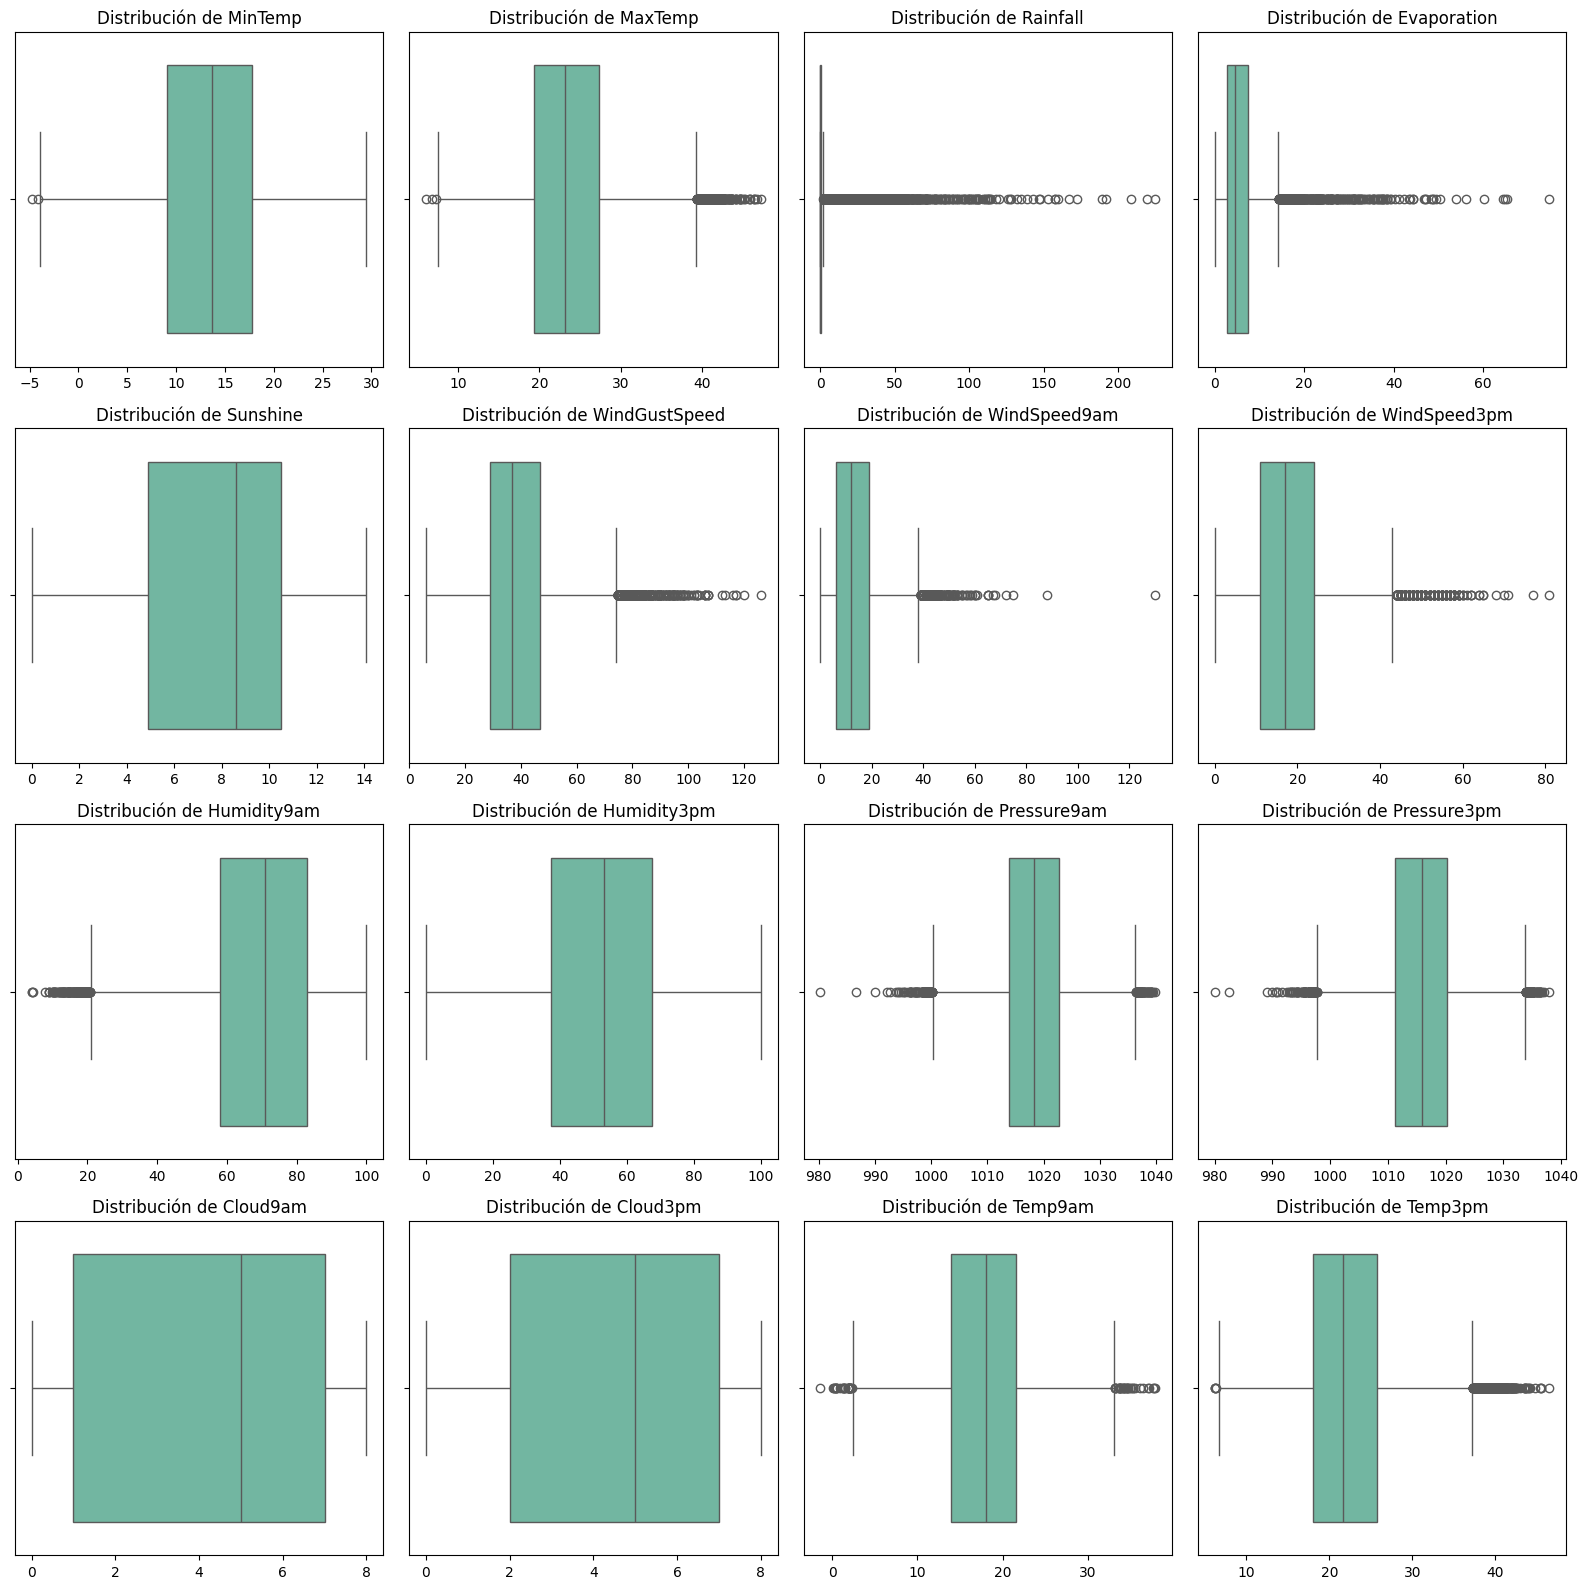

In [131]:
warnings.filterwarnings('ignore', category=FutureWarning)
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(colum_num):
    sns.boxplot(data=X_train, x=col, ax=axes[i], palette="Set2", legend=False)
    axes[i].set_title(f'Distribución de {col}', fontsize=12)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Las variables MinTemp, MaxTemp, Temp9am, Temp3pm, Pressure9am, Pressure3pm, WindGustSpeed, WindSpeed3pm presentan una distribución con tendencia a normal pero tienen bastantes valores atipicos. Humidity3pm tiene una distribución normal sin valores atipicos.

Las variables Rainfall, Evaporation presenta una asimetria hacia la derecha muy pronunciada, cercana a 0, con presencia de muchos valores atipicos. Mientras que WindSpeed9am también presenta esta asimetria en menor medida.

Humidity9am, Sunshine estan sesgada hacia la izquierda con la diferencia que Sunshine no tiene valores atipicos mientras que Humidity9am si, en su cola derecha.

Cloud9am y Cloud3pm como son octetos del 0-8 no presentan valores atipicos.

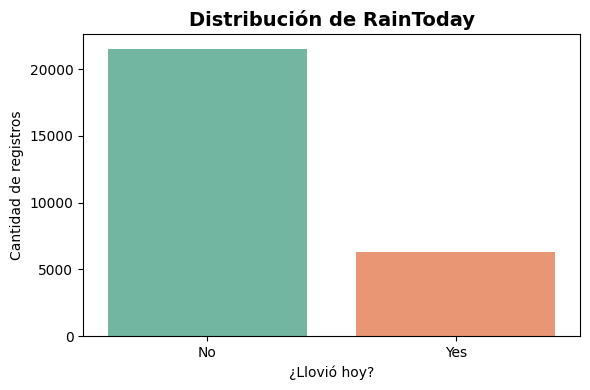

In [132]:
plt.figure(figsize=(6, 4))
sns.countplot(data=X_train, x='RainToday', palette='Set2')
plt.title('Distribución de RainToday', fontsize=14, fontweight='bold')
plt.xlabel('¿Llovió hoy?')
plt.ylabel('Cantidad de registros')
plt.tight_layout()
plt.show()

Se observa que la mayoria de los días que estan registrados no llovio. Mientras que los días que si llovio es mucho menor.

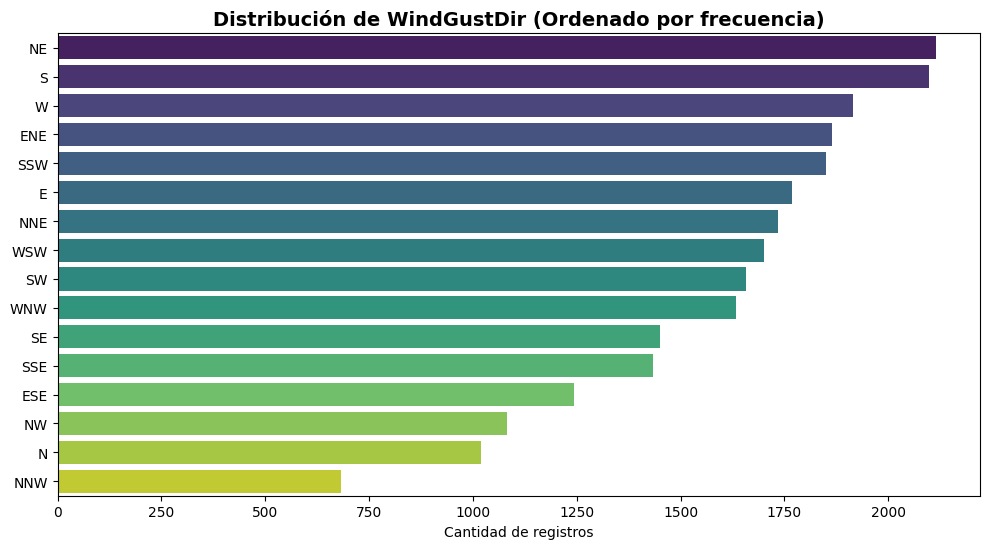

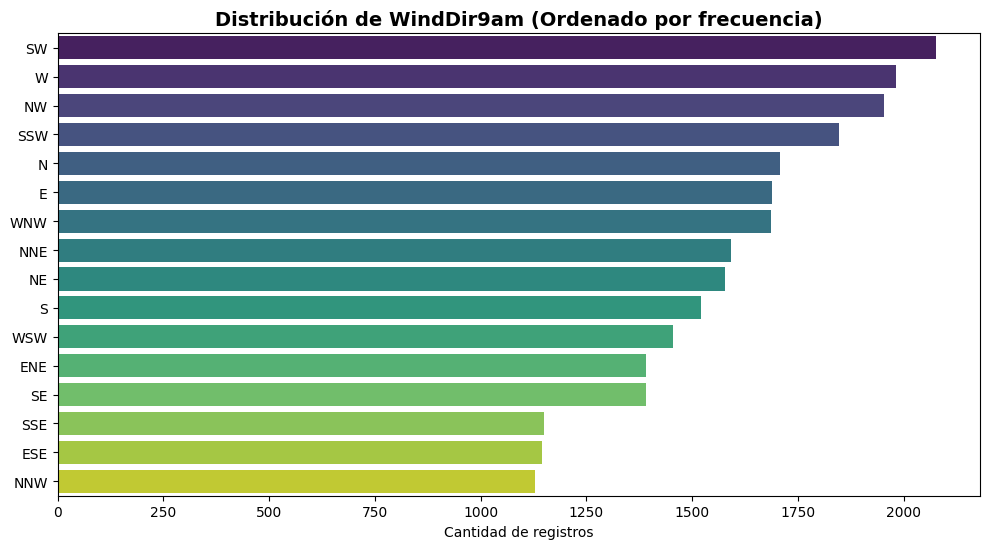

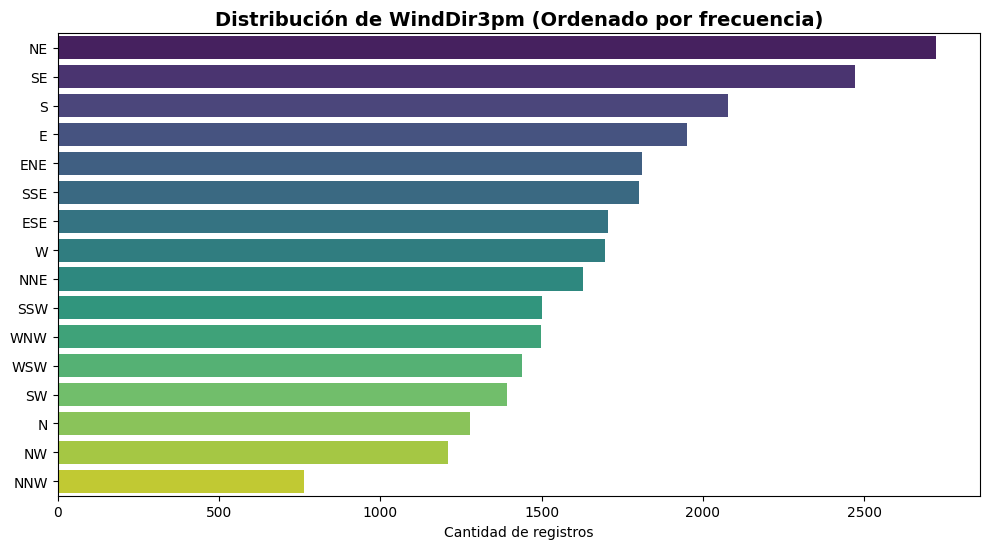

In [133]:
for col in ['WindGustDir', 'WindDir9am', 'WindDir3pm']:

    cant_categorias = X_train[col].nunique()
    plt.figure(figsize=(10, max(4, cant_categorias * 0.35)))

    orden_frecuencia = X_train[col].value_counts().index

    sns.countplot(data=X_train, y=col, order=orden_frecuencia, palette='viridis')
    plt.title(f'Distribución de {col} (Ordenado por frecuencia)', fontsize=14, fontweight='bold')
    plt.xlabel('Cantidad de registros')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

WindGustDir: Los vientos más fuerte registrados en su mayoria tienen dirección oeste, seguido de los vientos sudeste.
WindDir9am: Los vientos registrados a las 9 am suelen ser de mayor frecuencia en dirección Norte, seguido del Este.
WindDir3pm: Los vientos registrados a las 3 pm en su mayoria provienen del Sudeste, seguido por la dirección Oeste.

**Matriz de correlación**

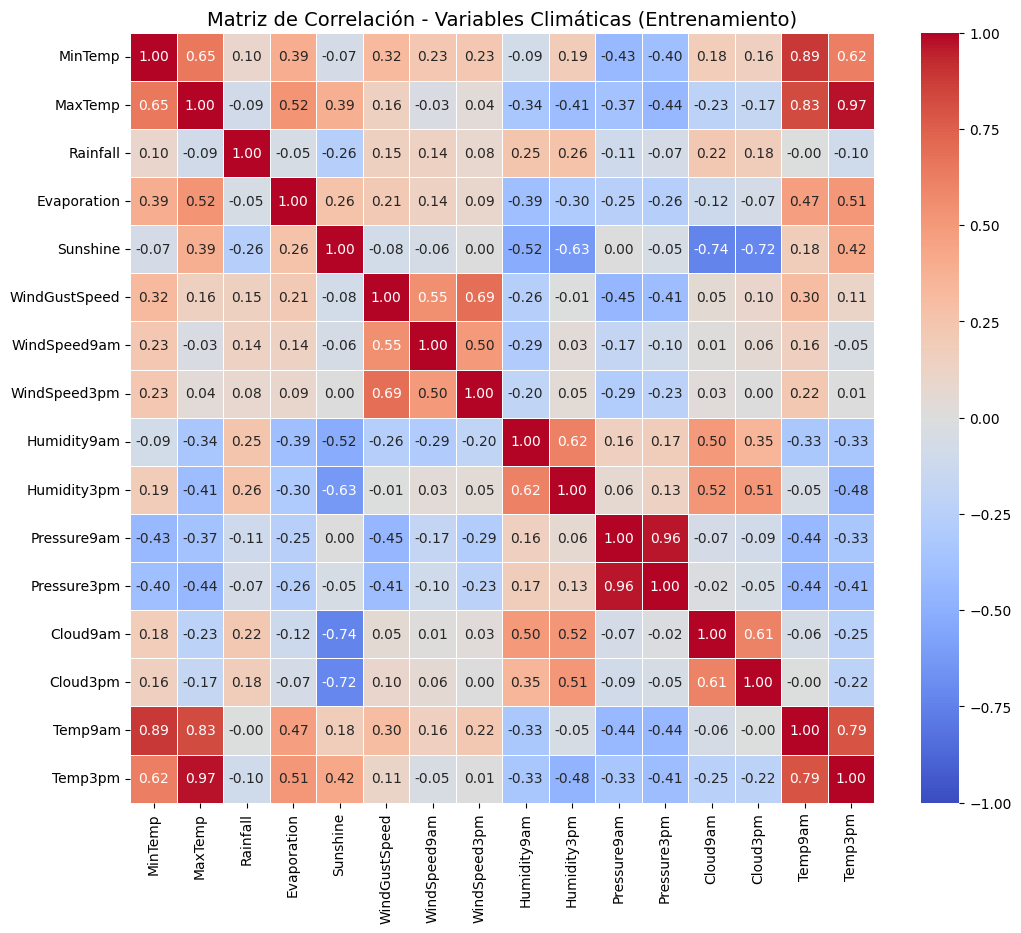

In [134]:
matriz_correlacion = X_train[colum_num].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5
)

plt.title("Matriz de Correlación - Variables Climáticas (Entrenamiento)", fontsize=14)
plt.show()

Se observan correlaciones altas entre:

- MinTemp y Temp9am (>0.9): miden temperaturas en momentos cercanos del día.
- MaxTemp y Temp3pm (>0.9): mismo motivo.
- Pressure9am y Pressure3pm (>0.95): la presión varía poco en el día.

- Sunshine y Cloud3pm: Correlación negativa fuerte (-0.70): A más horas de sol, menos nubes a la tarde.


Sunshine y Cloud3pm muestran correlación negativa.

En la matriz de correlación se visualiza un alto nivel de multicolinealidad (coeficientes > 0.90). Las variables Temp3pm, Temp9am y Pressure3pm aportan información duplicada respecto a las temperaturas extremas (MaxTemp, MinTemp) y la presión matutina (Pressure9am). Mantenerlas no mejora la predicción y aumenta el riesgo de sobreajuste (overfitting).

Para evitar ruido y simplificar el algoritmo, se eliminaron estas tres columnas. Para mantener la coherencia de los datos, la eliminación se aplicó por igual a los conjuntos de entrenamiento (X_train), validación (X_val) y prueba (X_test).

In [135]:

columnas_a_eliminar = ['Temp3pm', 'Temp9am', 'Pressure3pm']


X_train = X_train.drop(columns=columnas_a_eliminar)


print("Dimensiones de X_train después de limpiar:", X_train.shape)

Dimensiones de X_train después de limpiar: (28208, 21)


In [136]:
X_test = X_test.drop(columns=columnas_a_eliminar)

In [137]:
X_val = X_val.drop(columns=columnas_a_eliminar)

**Distribución de la target**

--Balance de la variable target--
RainTomorrow
No     21818
Yes     6390
Name: count, dtype: int64

RainTomorrow
No     0.773
Yes    0.227
Name: proportion, dtype: float64


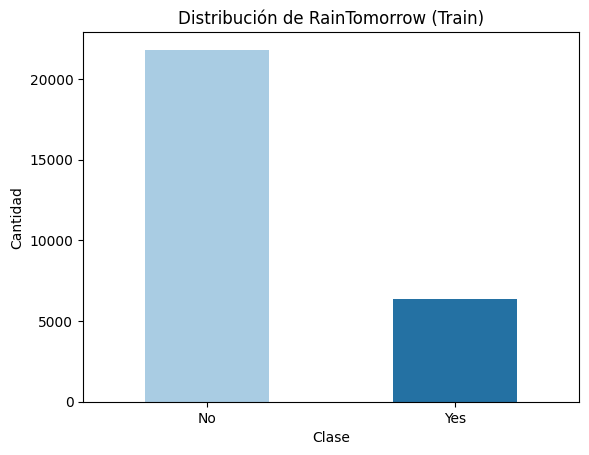

In [138]:
print("--Balance de la variable target--")
print(y_train.value_counts())
print()
print(y_train.value_counts(normalize=True).round(3))

y_train.value_counts().plot(kind='bar', color=['#A9CCE3', '#2471A3'])
plt.title('Distribución de RainTomorrow (Train)')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.show()

El dataset está muy desbalanceado: aproximadamente el 78% de los días no llueve y solo el 22%
sí lo hace.


In [139]:
# Observación de los datos únicos de las localidades
X_train['Location'].unique()

array(['Richmond', 'Sydney', 'BadgerysCreek', 'Williamtown', 'NorahHead',
       'Cobar', 'CoffsHarbour', 'WaggaWagga', 'NorfolkIsland', 'Albury',
       'Newcastle', 'Wollongong', 'SydneyAirport', 'Penrith', 'Moree'],
      dtype=object)

Se identifican 49 ciudades únicas. Agruparlas en 5 zonas climáticas
(Tropical, Subtropical, Árida, Mediterránea, Templada-SE) permite reducir
la cardinalidad de la variable manteniendo la información geográfica relevante.

**Se dividen las ciudades por zonas climáticas**

Las ciudades fueron agrupadas según similitudes climáticas y geográficas con el objetivo de reducir cardinalidad y mejorar la capacidad de generalización del modelo.

In [140]:
# Mapeo de ciudades a zonas climáticas
zone_map = {
    # Tropical (norte)
    'Darwin':           'Tropical',
    'Katherine':        'Tropical',
    'Cairns':           'Tropical',
    'Townsville':       'Tropical',

    # Subtropical (costa este)
    'Brisbane':         'Subtropical',
    'GoldCoast':        'Subtropical',
    'CoffsHarbour':     'Subtropical',
    'NorahHead':        'Subtropical',
    'Newcastle':        'Subtropical',
    'Williamtown':      'Subtropical',
    'NorfolkIsland':    'Subtropical',
    'Moree':            'Subtropical',

    # Árida (centro)
    'AliceSprings':     'Árida',
    'Uluru':            'Árida',
    'Woomera':          'Árida',
    'Cobar':            'Árida',
    'Mildura':          'Árida',
    'Nhil':             'Árida',

    # Mediterránea (suroeste)
    'Perth':            'Mediterránea',
    'PerthAirport':     'Mediterránea',
    'PearceRAAF':       'Mediterránea',
    'SalmonGums':       'Mediterránea',
    'Walpole':          'Mediterránea',
    'Witchcliffe':      'Mediterránea',
    'Albany':           'Mediterránea',
    'Nuriootpa':        'Mediterránea',

    # Templada-SE (sureste + Tasmania)
    'Sydney':           'Templada-SE',
    'SydneyAirport':    'Templada-SE',
    'BadgerysCreek':    'Templada-SE',
    'Penrith':          'Templada-SE',
    'Wollongong':       'Templada-SE',
    'Richmond':         'Templada-SE',
    'WaggaWagga':       'Templada-SE',
    'Albury':           'Templada-SE',
    'Melbourne':        'Templada-SE',
    'MelbourneAirport': 'Templada-SE',
    'Watsonia':         'Templada-SE',
    'Ballarat':         'Templada-SE',
    'Bendigo':          'Templada-SE',
    'Sale':             'Templada-SE',
    'Adelaide':         'Templada-SE',
    'MountGambier':     'Templada-SE',
    'Portland':         'Templada-SE',
    'Dartmoor':         'Templada-SE',
    'Canberra':         'Templada-SE',
    'Tuggeranong':      'Templada-SE',
    'MountGinini':      'Templada-SE',
    'Hobart':           'Templada-SE',
    'Launceston':       'Templada-SE',
}

X_train['Zona'] = X_train['Location'].map(zone_map)
X_train = X_train.drop('Location', axis=1)

In [141]:
X_val['Zona'] = X_val['Location'].map(zone_map)
X_val = X_val.drop('Location', axis=1)

X_test['Zona'] = X_test['Location'].map(zone_map)
X_test = X_test.drop('Location', axis=1)

In [142]:
# Verificación del dataframe tras el mapeo de zonas
X_train.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,...,Humidity9am,Humidity3pm,Pressure9am,Cloud9am,Cloud3pm,RainToday,Year,Month,Day,Zona
0,16.5,24.4,0.0,NaN,NaN,SE,38.0,S,SE,8.0,...,63.8,65.4,1015.4,8.0,8.0,No,2015,11,21,Templada-SE
1,16.5,27.3,0.0,5.4,10.6,W,23.0,W,ENE,16.0,...,71.3,56.0,1013.7,2.0,2.0,No,2013,4,14,Templada-SE
2,17.1,27.7,0.0,NaN,NaN,SSE,31.0,SSE,SE,10.0,...,85.6,63.9,1002.4,NaN,NaN,No,2012,2,6,Templada-SE
3,3.8,17.9,0.0,NaN,NaN,WNW,46.0,W,WSW,12.0,...,59.0,31.4,1019.3,NaN,NaN,No,2012,8,3,Subtropical
4,2.2,19.2,0.0,NaN,NaN,WSW,21.0,NaN,WNW,0.0,...,99.6,46.7,1014.1,NaN,NaN,No,2012,6,30,Templada-SE


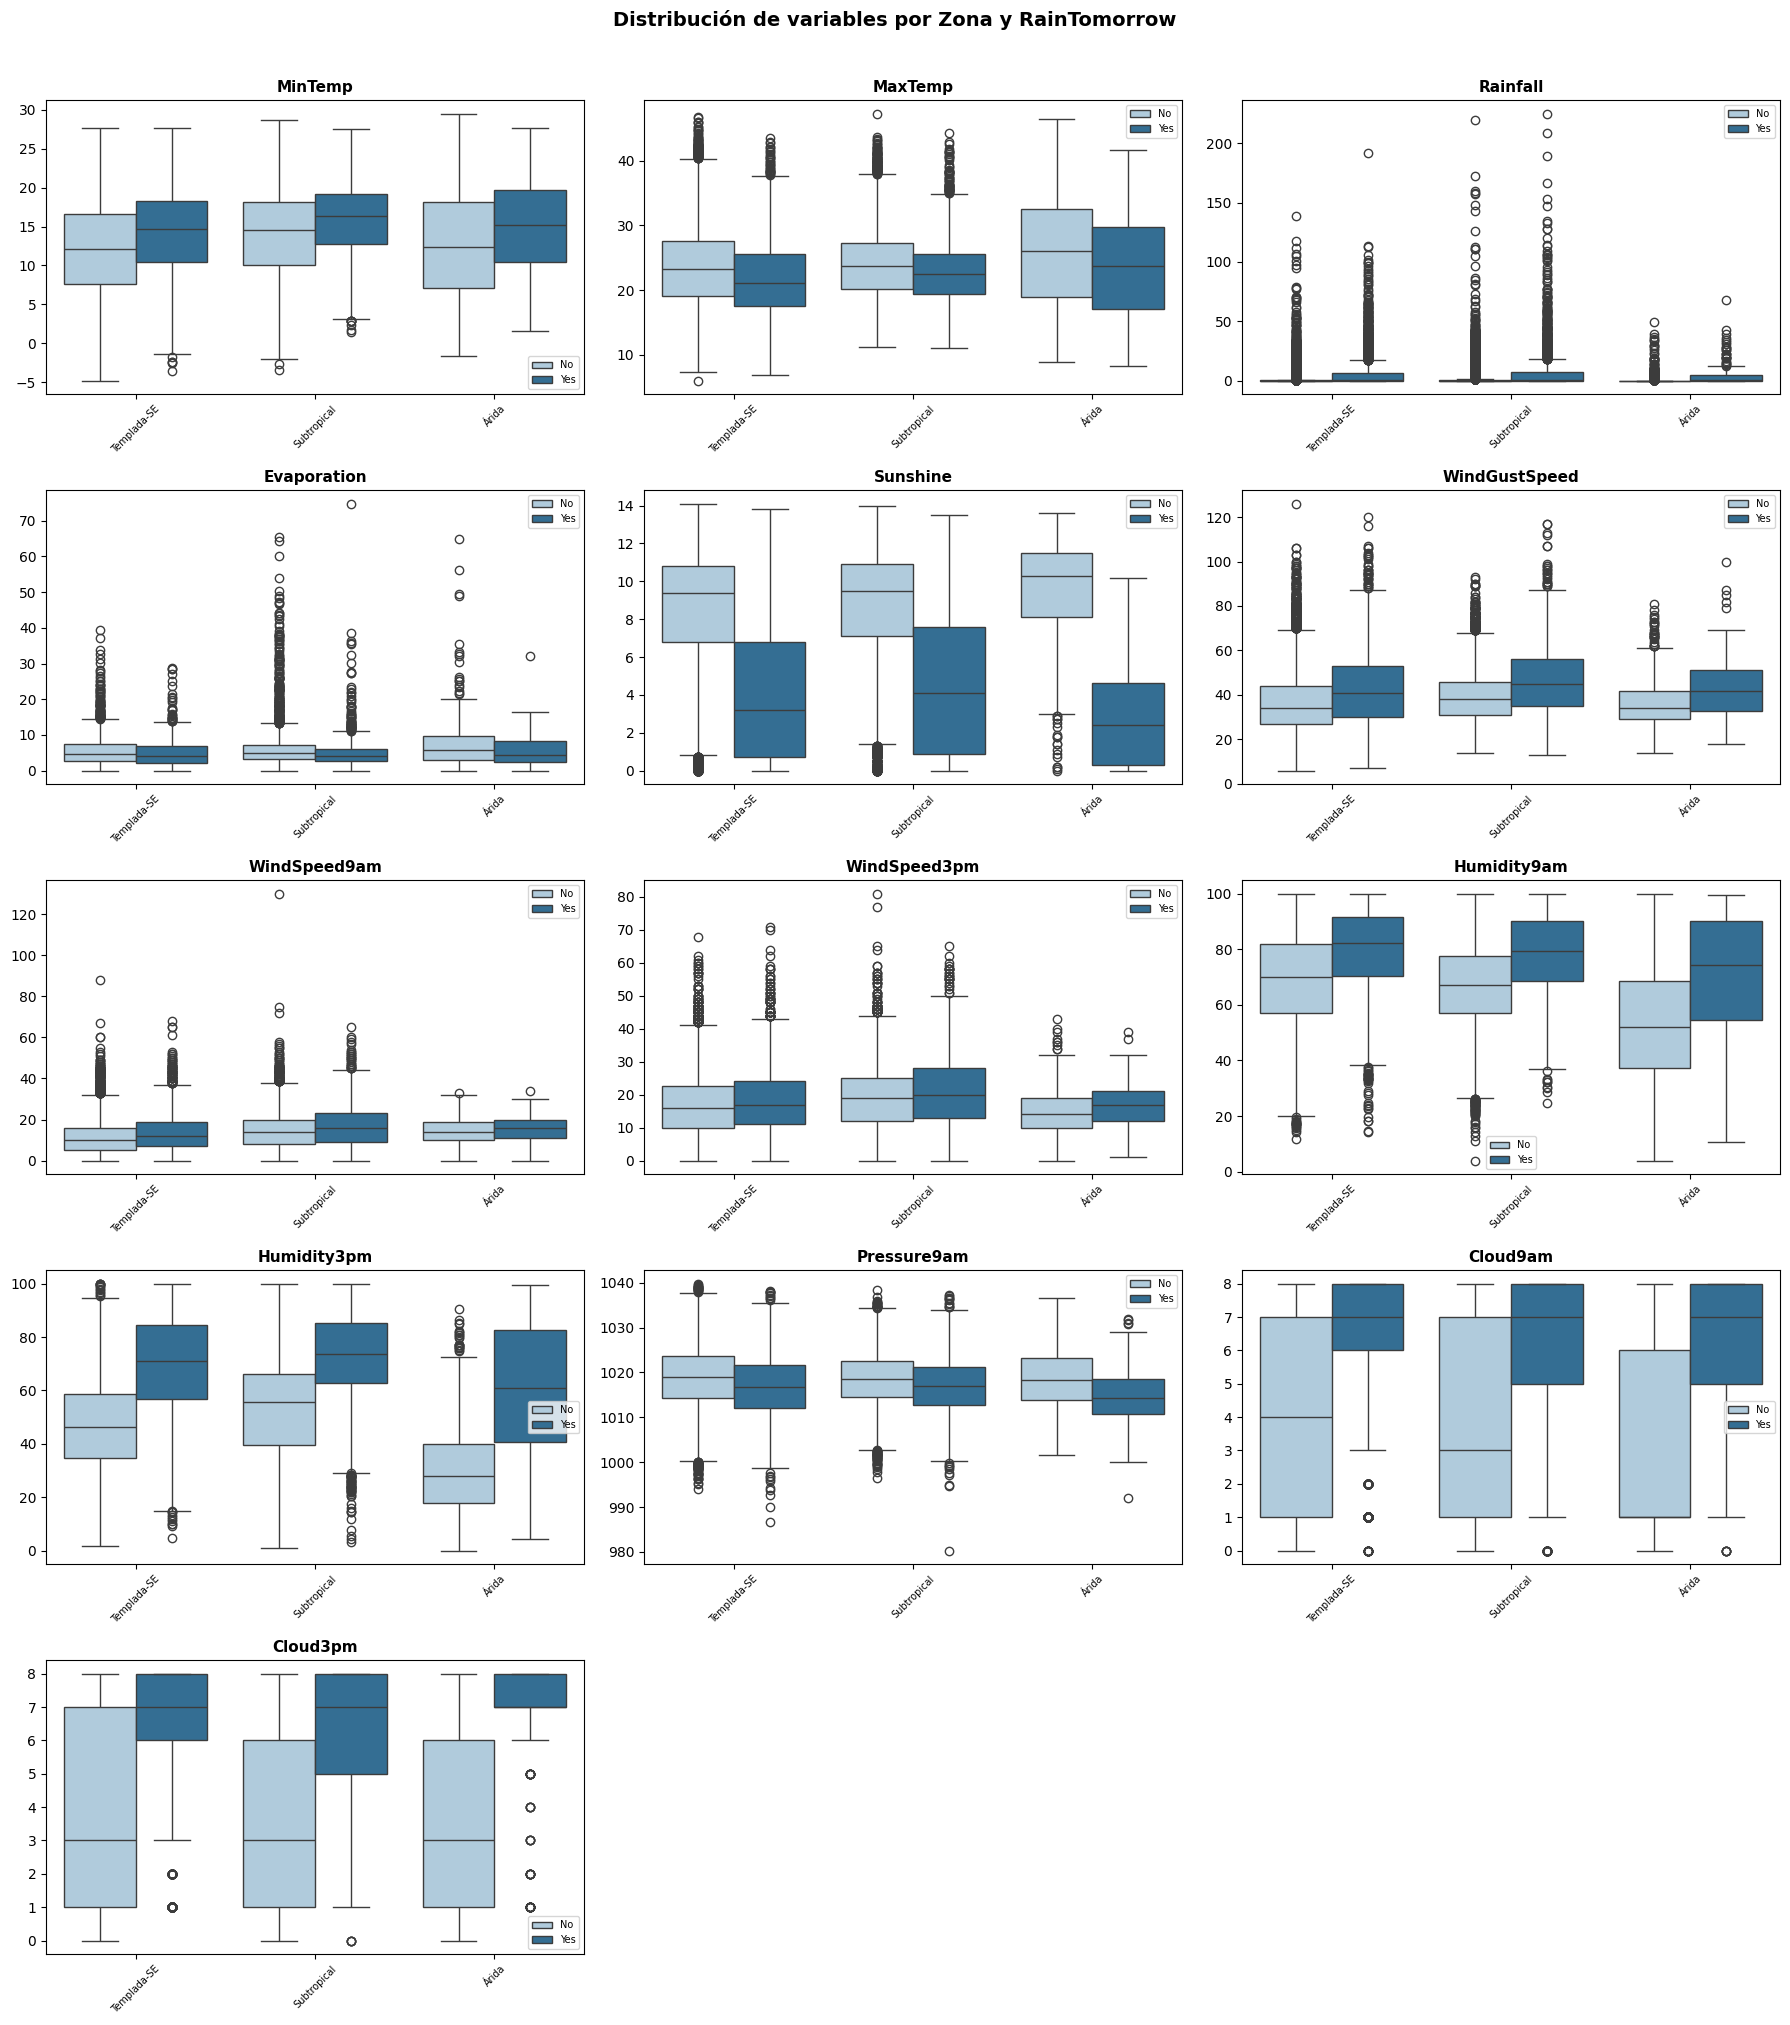

In [143]:
colum_num = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()

datos_eda = pd.concat([X_train, y_train], axis=1)
n_cols = 3
n_rows = (len(colum_num) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(colum_num):
    sns.boxplot(
        data=datos_eda,
        x='Zona',
        y=col,
        hue='RainTomorrow',
        palette={'No': '#A9CCE3', 'Yes': '#2471A3'},
        ax=axes[i]
    )
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)
    axes[i].legend(title='', fontsize=7)

# Ocultar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribución de variables por Zona y RainTomorrow',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Las variables que mejor separan días con y sin lluvia son Humidity3pm, Cloud3pm
y Sunshine: mayor humedad y nubosidad, y menor sol, se asocian con lluvia al
día siguiente. En cambio, WindSpeed y Rainfall muestran casi ninguna diferencia
entre clases.

La zona Tropical es la que presenta patrones más claros, mientras
que la Árida es la más homogénea.

La mayoría de las variables presentan valores atípicos, siendo Rainfall y
Evaporation las más afectadas debido a su distribución asimétrica.

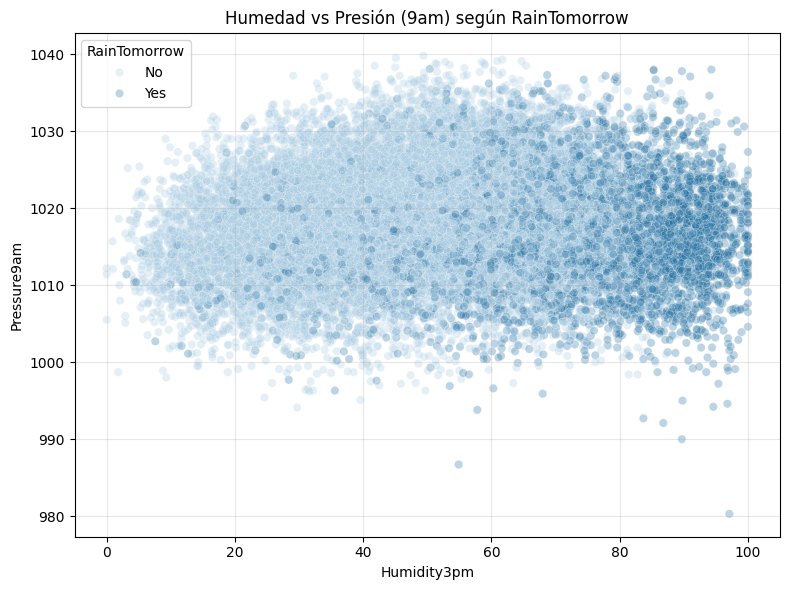

In [144]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=datos_eda,
    x='Humidity3pm',
    y='Pressure9am',
    hue='RainTomorrow',
    palette={'No': '#A9CCE3', 'Yes': '#2471A3'},
    alpha=0.3
)
plt.title('Humedad vs Presión (9am) según RainTomorrow')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Los días con lluvia al día siguiente tienden a concentrarse en valores de
humedad alta (>70%) y presión baja (<1015 hPa), confirmando el poder
predictivo de estas dos variables en combinación.

In [145]:
# Tabla de valores faltantes
faltantes = pd.DataFrame({
    'Columna': X_train.columns,
    'Cantidad': X_train.isnull().sum().values,
    'Porcentaje': (X_train.isnull().sum() / len(X_train) * 100).round(2).values
})
faltantes = faltantes[faltantes['Cantidad'] > 0].sort_values('Porcentaje', ascending=False)
print(faltantes)

          Columna  Cantidad  Porcentaje
4        Sunshine     17420       61.76
3     Evaporation     14234       50.46
15       Cloud3pm     11443       40.57
14       Cloud9am     11275       39.97
13    Pressure9am      4090       14.50
5     WindGustDir      2960       10.49
6   WindGustSpeed      2958       10.49
7      WindDir9am      2906       10.30
8      WindDir3pm      1252        4.44
10   WindSpeed3pm       839        2.97
12    Humidity3pm       752        2.67
9    WindSpeed9am       442        1.57
16      RainToday       387        1.37
2        Rainfall       387        1.37
11    Humidity9am       335        1.19
0         MinTemp       229        0.81
1         MaxTemp       116        0.41


Sunshine 48% nulos aproximadamente y Evaporation alrededor de 43% son las columnas con más valores
faltantes. Se decide imputar con la mediana en lugar de eliminarlas porque
contienen información climática relevante para predecir lluvia. La mediana es
más robusta que la media frente a distribuciones asimétricas y valores atípicos,
como las observadas en Rainfall y Evaporation.

Se observa que la zona Árida presenta las temperaturas máximas más altas y la menor
humedad, mientras que la zona Tropical muestra mayor evaporación. Estas diferencias
confirman que la variable Zona aporta información relevante para el modelo.

De los violinplots y boxplots por zona se observa que Humidity3pm, Cloud3pm y
Sunshine son las variables con mayor separación entre días con y sin lluvia en
todas las zonas. La zona Árida presenta distribuciones más compactas y con menos
diferencia entre clases, lo que refleja su menor variabilidad climática.

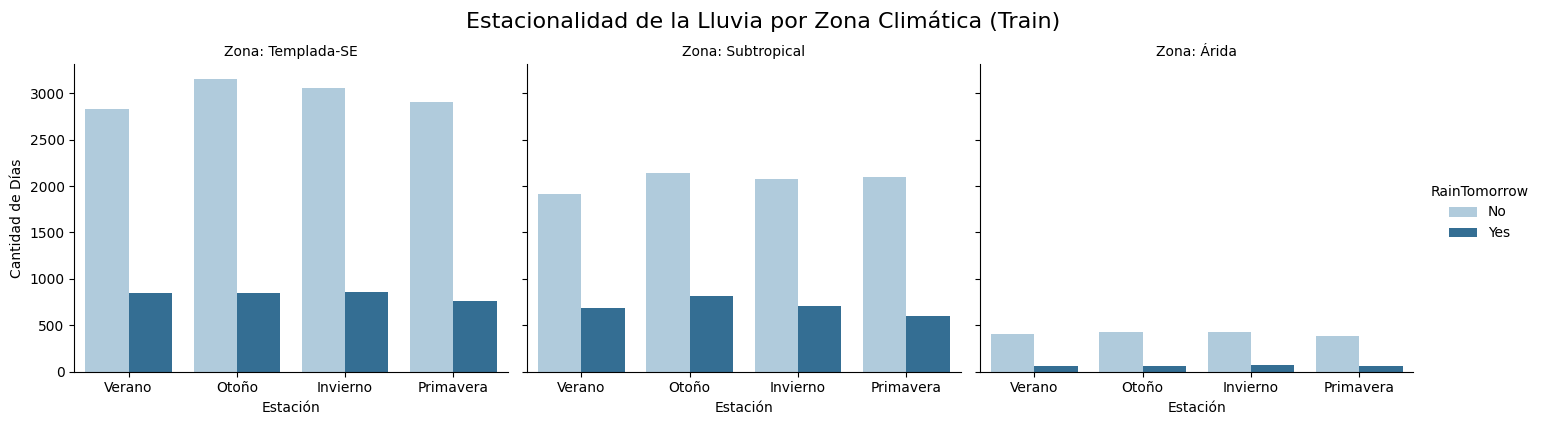

In [146]:
mapeo_estaciones = {
    12: 'Verano', 1: 'Verano', 2: 'Verano',
    3: 'Otoño', 4: 'Otoño', 5: 'Otoño',
    6: 'Invierno', 7: 'Invierno', 8: 'Invierno',
    9: 'Primavera', 10: 'Primavera', 11: 'Primavera'
}
datos_eda['Estacion'] = datos_eda['Month'].map(mapeo_estaciones)
X_train['Estacion'] = X_train['Month'].map(mapeo_estaciones)
X_val['Estacion']   = X_val['Month'].map(mapeo_estaciones)
X_test['Estacion']  = X_test['Month'].map(mapeo_estaciones)

g = sns.catplot(
    data=datos_eda,
    x='Estacion',
    hue='RainTomorrow',
    col='Zona',
    kind='count',
    col_wrap=3,
    order=['Verano', 'Otoño', 'Invierno', 'Primavera'],
    palette={'No': '#A9CCE3', 'Yes': '#2471A3'},
    height=4,
    aspect=1.2,
    sharex=False
)


g.set_axis_labels("Estación", "Cantidad de Días")
g.set_titles("Zona: {col_name}")
g.fig.suptitle('Estacionalidad de la Lluvia por Zona Climática (Train)', y=1.05, fontsize=16)

plt.show()

Se observa que la zona Tropical concentra más lluvia en verano, mientras que
la zona Mediterránea muestra el patrón inverso con más lluvia en invierno. La zona
Árida tiene poca lluvia en todas las estaciones. La zona Templada tiene mayores dias de lluvia, con mayor ocurrencia en invierno. Mientras que la subtropical se mantiene estable en todas las estaciones.

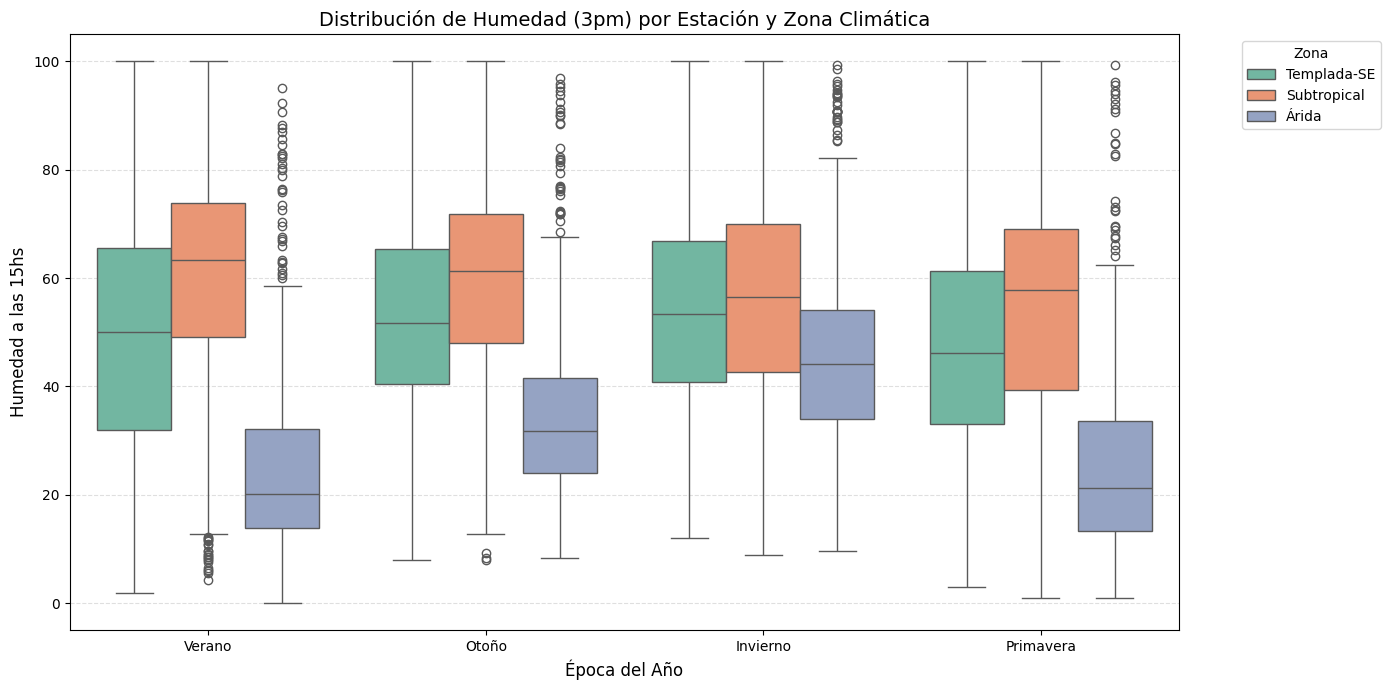

In [147]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=datos_eda,
    x='Estacion',
    y='Humidity3pm',
    hue='Zona',
    order=['Verano', 'Otoño', 'Invierno', 'Primavera'],
    palette='Set2'
)

plt.title('Distribución de Humedad (3pm) por Estación y Zona Climática', fontsize=14)
plt.xlabel('Época del Año', fontsize=12)
plt.ylabel('Humedad a las 15hs', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.legend(title='Zona', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

La zona Árida muestra la menor humedad en todas las estaciones, mientras que
la zona Tropical mantiene niveles altos durante todo el año. En la zona
Mediterránea se observa mayor humedad en invierno, consistente con su régimen
de lluvias invernales.

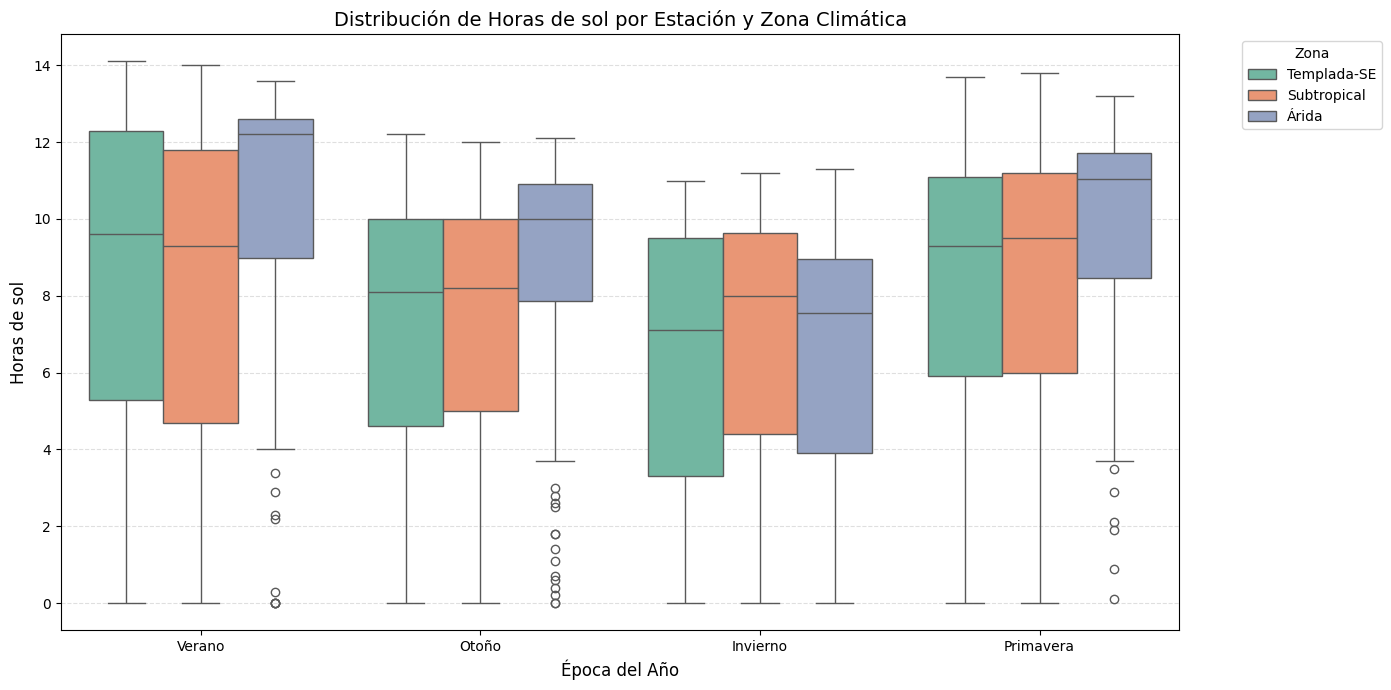

In [148]:
plt.figure(figsize=(14, 7))

# Dibujamos un diagrama de caja donde el color (hue) separa por Zona
sns.boxplot(
    data=datos_eda,
    x='Estacion',
    y='Sunshine',
    hue='Zona',
    order=['Verano', 'Otoño', 'Invierno', 'Primavera'],
    palette='Set2'
)

plt.title('Distribución de Horas de sol por Estación y Zona Climática', fontsize=14)
plt.xlabel('Época del Año', fontsize=12)
plt.ylabel('Horas de sol', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Movemos la leyenda afuera para que no tape los datos
plt.legend(title='Zona', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

La zona Árida registra la mayor cantidad de horas de sol en todas las estaciones,
lo que es coherente con su escasa nubosidad. La zona Tropical muestra menos horas
de sol en verano, coincidiendo con la época de lluvias. En general,
todas las zonas presentan más sol en verano que en invierno, con excepción de
la zona Mediterránea donde el patrón se invierte levemente.

Se eliminan las columnas de año y día, ya que no son relevantes para nuestro modelo, se conserva la variable mes porque se uso para crear la variable estación que resume mejor la época del año.

In [149]:
X_train = X_train.drop(columns=['Year', 'Day'])
X_val   = X_val.drop(columns=['Year', 'Day'])
X_test  = X_test.drop(columns=['Year', 'Day'])

# **Regresión Logística**

In [150]:
colum_num = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
colum_cat = X_train.select_dtypes(include=['object']).columns.tolist()

print("Numéricas:", colum_num)
print("Categóricas:", colum_cat)

Numéricas: ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Cloud9am', 'Cloud3pm']
Categóricas: ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'Zona', 'Estacion']


Las variables categóricas son: WindGustDir, WindDir9am, WindDir3pm, RainToday y Zona.
Se aplica OneHotEncoding, que crea una columna binaria por cada categoría posible.


Para las variables numéricas se imputó agrupando por Zona y Estación
porque el clima australiano varía mucho según la geografía y época del año.


Las medianas se calcularon solo sobre X_train para evitar fuga de datos.

In [151]:

cols_mediana = ['Rainfall', 'Evaporation']
cols_knn = ['MinTemp', 'MaxTemp', 'Sunshine', 'Humidity9am', 'Humidity3pm',
            'WindGustSpeed', 'Pressure9am', 'Cloud9am',
            'Cloud3pm', 'WindSpeed9am', 'WindSpeed3pm']
cols_todas_num = cols_mediana + cols_knn


medianas_agrupadas = X_train.groupby(['Zona', 'Estacion'])[cols_todas_num].median()


medianas_globales = X_train[cols_todas_num].median()


def imputar_por_zona_estacion(df, med_agrupadas, med_globales, columnas):
    df_imputado = df.copy()

    for col in columnas:
        def rellenar_grupo(grupo):

            if grupo.name in med_agrupadas.index and pd.notna(med_agrupadas.loc[grupo.name, col]):
                valor_imputar = med_agrupadas.loc[grupo.name, col]
            else:
                valor_imputar = med_globales[col]

            return grupo.fillna(valor_imputar)

        df_imputado[col] = df_imputado.groupby(['Zona', 'Estacion'], group_keys=False)[col].apply(rellenar_grupo)

    return df_imputado

X_train = imputar_por_zona_estacion(X_train, medianas_agrupadas, medianas_globales, cols_todas_num)
X_val   = imputar_por_zona_estacion(X_val, medianas_agrupadas, medianas_globales, cols_todas_num)
X_test  = imputar_por_zona_estacion(X_test, medianas_agrupadas, medianas_globales, cols_todas_num)

print("Nulos en X_train numéricas:", X_train[cols_todas_num].isnull().sum().sum())

Nulos en X_train numéricas: 0


In [152]:
colum_num = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
colum_cat = X_train.select_dtypes(include=['object']).columns.tolist()


pipeline_num = Pipeline([
    ('scaler', StandardScaler())
])

pipeline_cat = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocesador = ColumnTransformer([
    ('num', pipeline_num, colum_num),
    ('cat', pipeline_cat, colum_cat)
])


y_train_enc = (y_train == 'Yes').astype(int)
y_val_enc   = (y_val   == 'Yes').astype(int)

modelo_lr = Pipeline([
    ('preprocesador', preprocesador),
    ('modelo', LogisticRegression(max_iter=1000, random_state=42))
])

modelo_lr.fit(X_train, y_train_enc)
y_pred = modelo_lr.predict(X_val)

# 4. Métricas
print("Accuracy: ", round(accuracy_score(y_val_enc, y_pred), 4))
print("Precision:", round(precision_score(y_val_enc, y_pred), 4))
print("Recall:   ", round(recall_score(y_val_enc, y_pred), 4))
print("F1 Score: ", round(f1_score(y_val_enc, y_pred), 4))

Accuracy:  0.8429
Precision: 0.7298
Recall:    0.4869
F1 Score:  0.5841


Aunque el modelo logra un Accuracy alto 84% aprox, este valor es engañoso por el desbalance de los datos (acierta principalmente los días que no llueve). Su mayor debilidad es el Recall 48%, esto significa que falla en detectar más de la mitad de los casos reales de lluvia, generando una alta tasa de falsos negativos.

El modelo no logra detectar más de la mitad de los días que realmente llueve (muchos falsos negativos).

Si bien su Precisión del 70% es buena, cuando decide predecir lluvia, el bajo F1-Score 57% confirma que, al modelo le cuesta mucho identificar si llueve.

**Validación cruzada**

In [153]:
scores = cross_val_score(
    modelo_lr,
    X_train,
    y_train_enc,
    cv=5,
    scoring='f1'
)
print("Scores F1:", scores)
print("F1 promedio:", np.mean(scores))
print("Desvío estándar:", np.std(scores))

Scores F1: [0.57964185 0.54757463 0.57397839 0.58285164 0.58780037]
F1 promedio: 0.5743693750484501
Desvío estándar: 0.014129761202445494


Al tener un desvío estándar casi nulo, comprobamos que el rendimiento (F1 promedio de 0.58 aprox.) no varía casi nada sin importar cómo se dividan los datos.

Esto garantiza que el modelo generaliza bien y que nuestros resultados son confiables, aunque sigan reflejando el límite que tiene el algoritmo frente al desbalance de clases.

In [154]:

print("MCC:", round(matthews_corrcoef(y_val_enc, y_pred), 4))

MCC: 0.5073


Como métrica adicional se eligió el MCC (Matthews Correlation Coefficient),
El MCC es de 0.493, este valor cercano a 0.50 confirma un aprendizaje real y positivo. El modelo logra diferenciar los días con lluvia de los días sin lluvia mucho mejor que si predijera al azar, aunque todavía tiene bastante margen de mejora.

In [155]:
X_val_transformado = modelo_lr.named_steps['preprocesador'].transform(X_val)
print(X_val_transformado.shape)

(7053, 70)


Las dimensiones resultantes confirman que el preprocesamiento se aplicó correctamente. La cantidad de filas (días) se mantiene intacta, pero las columnas aumentaron a 72 porque el One-Hot Encoding expandió las variables categóricas (como la Zona o la Dirección del Viento), creando una nueva columna matemática (0 o 1) por cada categoría posible.

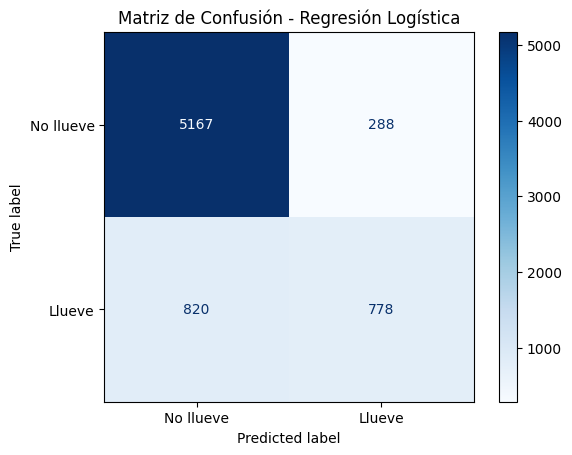

In [156]:
cm = confusion_matrix(y_val_enc, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No llueve', 'Llueve'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - Regresión Logística')
plt.show()

En los resultados de esta matriz: Se confirma que nuestro modelo generó una alta cantidad de falsos negativos (2621), lo que significa que no logró detectar más de la mitad de los días lluviosos reales (solo acertó en 2479).
En contraste, los falsos positivos (1297) se mantuvieron relativamente bajos.

Esto demuestra que acierta muy bien los días sin lluvia, pero falla frecuentemente cuando se trata de predecir si llueve.

**Curva ROC**

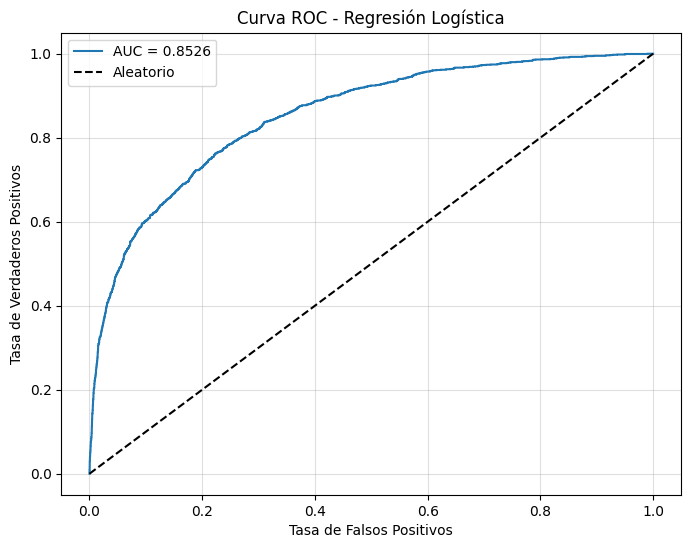

In [167]:
y_prob = modelo_lr.predict_proba(X_val)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val_enc, y_prob)
auc = roc_auc_score(y_val_enc, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Regresión Logística')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()


La curva ROC muestra un AUC de 0.8615, lo que indica que el modelo tiene
buena capacidad para distinguir días con y sin lluvia. La curva se aleja
claramente de la diagonal, confirmando que aprendió
patrones reales.

Con respecto a si 0.5 es el mejor umbral, no porque el dataset tiene muchos más días sin lluvia, por lo que
el modelo tiende a asignar probabilidades bajas de lluvia.

Con 0.5 de umbral la mayoría de los días de lluvia real quedan por debajo
y se clasifican incorrectamente.

Para optimizar el umbral se debe analizar la curva ROC calculando la variación de la Tasa de Verdaderos Positivos (TPR) y la Tasa de Falsos Positivos (FPR) para cada valor
.

Para encontrar este mejor umbral debemos buscar aquel punto que se acerque lo máximo posible a la coordenada (0,1), que representa la clasificación perfecta.

**Comparación de modelos: Train y Val**

In [158]:
y_pred_train = modelo_lr.predict(X_train)
print("--- Train ---")
print("Accuracy:", round(accuracy_score(y_train_enc, y_pred_train), 4))
print("F1 Score:", round(f1_score(y_train_enc, y_pred_train), 4))
print("--- Validación ---")
print("Accuracy:", round(accuracy_score(y_val_enc, y_pred), 4))
print("F1 Score:", round(f1_score(y_val_enc, y_pred), 4))

--- Train ---
Accuracy: 0.8395
F1 Score: 0.5735
--- Validación ---
Accuracy: 0.8429
F1 Score: 0.5841


Existe muy poca diferencia entre ambos conjuntos, lo que indica que
el modelo no presenta overfitting, es decir, aprendió a generalizar correctamente
a los datos nuevos.

# Implementación de modelo base


In [159]:
# Modelo base estratificado: predice respetando la proporción de clases
dummy_strat = DummyClassifier(strategy='stratified', random_state=42)
dummy_strat.fit(X_train, y_train_enc)
y_pred_dummy_strat = dummy_strat.predict(X_val)

print("Modelo Base Estratificado:")
print("Accuracy: ", round(accuracy_score(y_val_enc, y_pred_dummy_strat), 4))
print("Precision:", round(precision_score(y_val_enc, y_pred_dummy_strat, zero_division=0), 4))
print("Recall:   ", round(recall_score(y_val_enc, y_pred_dummy_strat, zero_division=0), 4))
print("F1 Score: ", round(f1_score(y_val_enc, y_pred_dummy_strat, zero_division=0), 4))

Modelo Base Estratificado:
Accuracy:  0.6592
Precision: 0.2459
Recall:    0.2441
F1 Score:  0.245


El modelo estratificado predice aleatoriamente respetando la proporción
de clases (78%/22%). Obtiene Accuracy de 0.65, Precision y Recall de 0.22
y F1 de 0.22. Si bien detecta algo de lluvia (a diferencia del most_frequent),
lo hace al azar sin aprender ningún patrón real.

**Matriz de confusión - Modelo Base**

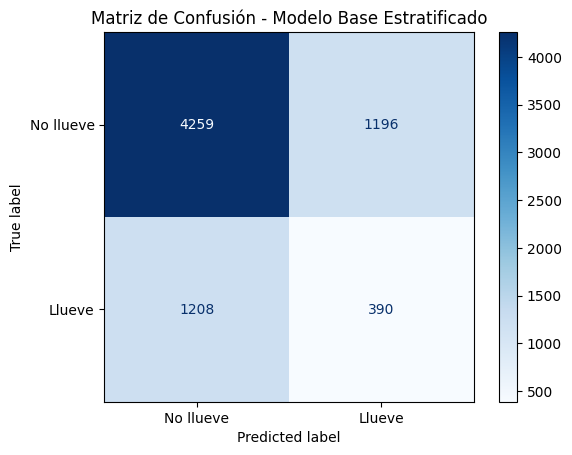

In [160]:
cm_strat = confusion_matrix(y_val_enc, y_pred_dummy_strat)
disp_strat = ConfusionMatrixDisplay(cm_strat, display_labels=['No llueve', 'Llueve'])
disp_strat.plot(cmap='Blues')
plt.title('Matriz de Confusión - Modelo Base Estratificado')
plt.show()


El modelo base acierta 4259 días sin lluvia y 390 días con
lluvia, pero genera 1196 falsas alarmas y se pierde 1208 días de lluvia
real.

Los aciertos de lluvia son bajos, confirmando que el modelo no tiene capacidad predictiva real.

**Curva ROC - Modelo Base**

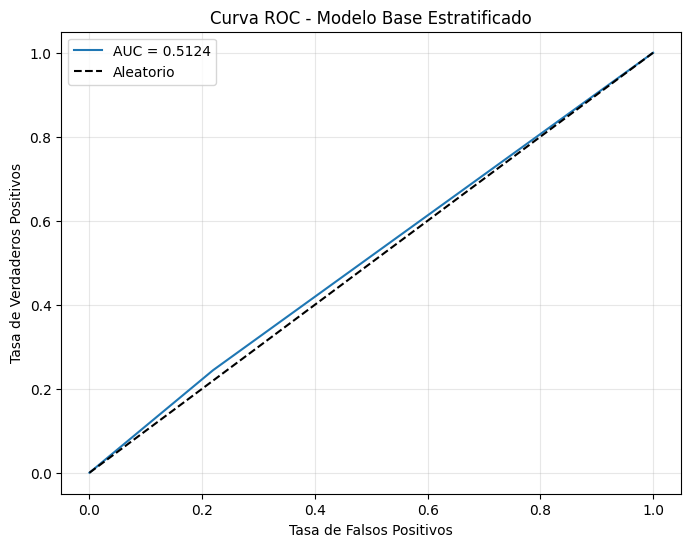

In [161]:
y_prob_strat = dummy_strat.predict_proba(X_val)[:, 1]
fpr_s, tpr_s, _ = roc_curve(y_val_enc, y_prob_strat)
auc_s = roc_auc_score(y_val_enc, y_prob_strat)

plt.figure(figsize=(8, 6))
plt.plot(fpr_s, tpr_s, label=f'AUC = {auc_s:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Modelo Base Estratificado')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

El AUC de 0.5124 confirma que el modelo estratificado no tiene ninguna
capacidad discriminativa real, equivale a predecir al azar.

In [162]:
acc_lr  = round(accuracy_score(y_val_enc, y_pred), 4)
rec_lr  = round(recall_score(y_val_enc, y_pred), 4)
f1_lr   = round(f1_score(y_val_enc, y_pred), 4)

acc_dummy = round(accuracy_score(y_val_enc, y_pred_dummy_strat), 4)
rec_dummy = round(recall_score(y_val_enc, y_pred_dummy_strat, zero_division=0), 4)
f1_dummy  = round(f1_score(y_val_enc, y_pred_dummy_strat, zero_division=0), 4)

print(f"{'Métrica':<12} {'Dummy':>10} {'Log. Reg.':>10}")
print(f"{'Accuracy':<12} {acc_dummy:>10} {acc_lr:>10}")
print(f"{'Recall':<12} {rec_dummy:>10} {rec_lr:>10}")
print(f"{'F1 Score':<12} {f1_dummy:>10} {f1_lr:>10}")

Métrica           Dummy  Log. Reg.
Accuracy         0.6592     0.8429
Recall           0.2441     0.4869
F1 Score          0.245     0.5841


La regresión logística supera al modelo base en todas las
métricas. El DummyClassifier obtiene Accuracy 0.65, Recall 0.24 y F1 0.24 prediciendo
al azar sin aprender ningún patrón real.

La regresión logística mejora significativamente: Accuracy 0.84, Recall 0.49
y F1 0.58, confirmando que sí aprendió relaciones entre las variables y la
probabilidad de lluvia.

**Gráfico comparativo**

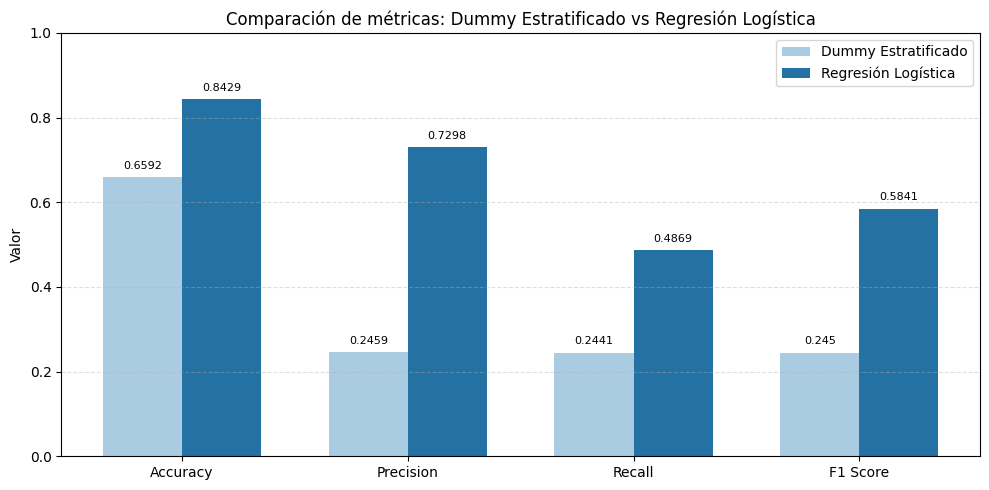

In [168]:
metricas = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
valores_dummy = [
    round(accuracy_score(y_val_enc, y_pred_dummy_strat), 4),
    round(precision_score(y_val_enc, y_pred_dummy_strat, zero_division=0), 4),
    round(recall_score(y_val_enc, y_pred_dummy_strat, zero_division=0), 4),
    round(f1_score(y_val_enc, y_pred_dummy_strat, zero_division=0), 4)
]
valores_lr = [
    round(accuracy_score(y_val_enc, y_pred), 4),
    round(precision_score(y_val_enc, y_pred), 4),
    round(recall_score(y_val_enc, y_pred), 4),
    round(f1_score(y_val_enc, y_pred), 4)
]

x = range(len(metricas))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar([i - width/2 for i in x], valores_dummy, width, label='Dummy Estratificado', color='#A9CCE3')
plt.bar([i + width/2 for i in x], valores_lr, width, label='Regresión Logística', color='#2471A3')
plt.xticks(x, metricas)
plt.ylim(0, 1)
plt.title('Comparación de métricas: Dummy Estratificado vs Regresión Logística')
plt.ylabel('Valor')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
for i, (vd, vl) in enumerate(zip(valores_dummy, valores_lr)):
    plt.text(i - width/2, vd + 0.02, str(vd), ha='center', fontsize=8)
    plt.text(i + width/2, vl + 0.02, str(vl), ha='center', fontsize=8)
plt.tight_layout()
plt.show()

El gráfico confirma visualmente que la regresión logística supera al
modelo base en todas las métricas.

La diferencia más notable es en
Accuracy (0.65 vs 0.84) y F1 (0.22 vs 0.58).

# Conclusión


La regresión logística le gana al modelo base
en todas las métricas, sobre todo en Recall (0.49 vs 0.24) y F1 (0.58 vs 0.24),
lo que confirma que aprendió patrones reales del clima australiano.

Detectar solo el 49% de los días de lluvia real no es ideal,
optimizando el umbral de decisión este número mejoraría bastante.